In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor


In [2]:
X_df = pd.read_csv("smartphone_battery_features.csv")
y_df = pd.read_csv("smartphone_battery_targets.csv")
# load the dataset

In [3]:
X_df.shape, y_df.shape
# rows and coloums

((5000, 15), (5000, 3))

In [4]:
X_df.columns
# coloum names

Index(['Device_ID', 'device_age_months', 'battery_capacity_mah',
       'avg_screen_on_hours_per_day', 'avg_charging_cycles_per_week',
       'avg_battery_temp_celsius', 'fast_charging_usage_percent',
       'overnight_charging_freq_per_week', 'gaming_hours_per_week',
       'video_streaming_hours_per_week', 'background_app_usage_level',
       'signal_strength_avg', 'charging_habit_score', 'usage_intensity_score',
       'thermal_stress_index'],
      dtype='object')

In [5]:
y_df.columns
# target coloum names

Index(['Device_ID', 'current_battery_health_percent', 'recommended_action'], dtype='object')

In [6]:
y = y_df['current_battery_health_percent']   # use exact column name
# declare target

In [7]:
X_df.info()
y_df.info()
#info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Device_ID                         5000 non-null   object 
 1   device_age_months                 5000 non-null   int64  
 2   battery_capacity_mah              5000 non-null   int64  
 3   avg_screen_on_hours_per_day       5000 non-null   float64
 4   avg_charging_cycles_per_week      5000 non-null   float64
 5   avg_battery_temp_celsius          5000 non-null   float64
 6   fast_charging_usage_percent       5000 non-null   float64
 7   overnight_charging_freq_per_week  5000 non-null   int64  
 8   gaming_hours_per_week             5000 non-null   float64
 9   video_streaming_hours_per_week    5000 non-null   float64
 10  background_app_usage_level        5000 non-null   object 
 11  signal_strength_avg               5000 non-null   object 
 12  chargi

In [8]:
X_df.isnull().sum()
y.isnull().sum()
# null values

np.int64(0)

In [9]:
df = pd.concat([X_df, y], axis=1)
# concat 2 csv files 

In [10]:
df.describe()


,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,charging_habit_score,usage_intensity_score,thermal_stress_index,current_battery_health_percent
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,24.232400,4134.700000,5.514120,8.33224,31.907360,50.712400,3.465200,4.012920,10.020740,6.582000,9.998394,3.079366,62.595600
std,14.138004,745.061698,1.974704,3.03454,2.544528,22.227398,2.306307,2.834289,4.990648,1.225225,0.058542,0.674274,17.723528
min,0.000000,3000.000000,1.000000,3.00000,21.600000,1.100000,0.000000,0.000000,0.000000,3.000000,6.570000,1.000000,10.000000
25%,12.000000,4000.000000,4.200000,6.10000,30.200000,33.500000,1.000000,1.900000,6.600000,6.000000,10.000000,2.620000,50.200000
50%,24.000000,4500.000000,5.500000,8.25000,31.900000,51.000000,3.000000,3.300000,10.000000,7.000000,10.000000,3.070000,64.100000
75%,36.000000,5000.000000,6.900000,10.40000,33.600000,68.100000,5.000000,5.400000,13.400000,7.000000,10.000000,3.520000,76.900000
max,48.000000,5000.000000,12.000000,18.60000,41.200000,99.100000,7.000000,24.800000,27.200000,10.000000,10.000000,6.180000,100.000000


In [11]:
# Check what background_app_usage_level and signal_strength_avg look like
print("=== Background App Usage Level ===")
print(X_df['background_app_usage_level'].value_counts())
print(f"\nData type: {X_df['background_app_usage_level'].dtype}")
print(f"Unique values: {X_df['background_app_usage_level'].nunique()}")

print("\n=== Signal Strength Avg ===")
print(X_df['signal_strength_avg'].value_counts())
print(f"\nData type: {X_df['signal_strength_avg'].dtype}")
print(f"Unique values: {X_df['signal_strength_avg'].nunique()}")

=== Background App Usage Level ===
background_app_usage_level
Low       1707
Medium    1684
High      1609
Name: count, dtype: int64

Data type: object
Unique values: 3

=== Signal Strength Avg ===
signal_strength_avg
Good        3025
Moderate    1509
Poor         466
Name: count, dtype: int64

Data type: object
Unique values: 3


In [12]:
# Create working copy
X_df_encoded = X_df.copy()

# Ordinal encoding with proper order
background_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
signal_mapping = {'Poor': 0, 'Moderate': 1, 'Good': 2}

X_df_encoded['background_app_usage_level'] = X_df_encoded['background_app_usage_level'].map(background_mapping)
X_df_encoded['signal_strength_avg'] = X_df_encoded['signal_strength_avg'].map(signal_mapping)

print("✅ Encoded background_app_usage_level: Low=0, Medium=1, High=2")
print("✅ Encoded signal_strength_avg: Poor=0, Moderate=1, Good=2\n")

# Verify encoding
print("Encoded values for background_app_usage_level:", sorted(X_df_encoded['background_app_usage_level'].unique()))
print("Encoded values for signal_strength_avg:", sorted(X_df_encoded['signal_strength_avg'].unique()))


✅ Encoded background_app_usage_level: Low=0, Medium=1, High=2
✅ Encoded signal_strength_avg: Poor=0, Moderate=1, Good=2

Encoded values for background_app_usage_level: [np.int64(0), np.int64(1), np.int64(2)]
Encoded values for signal_strength_avg: [np.int64(0), np.int64(1), np.int64(2)]



=== STEP 2: Creating Complete Correlation Matrix ===



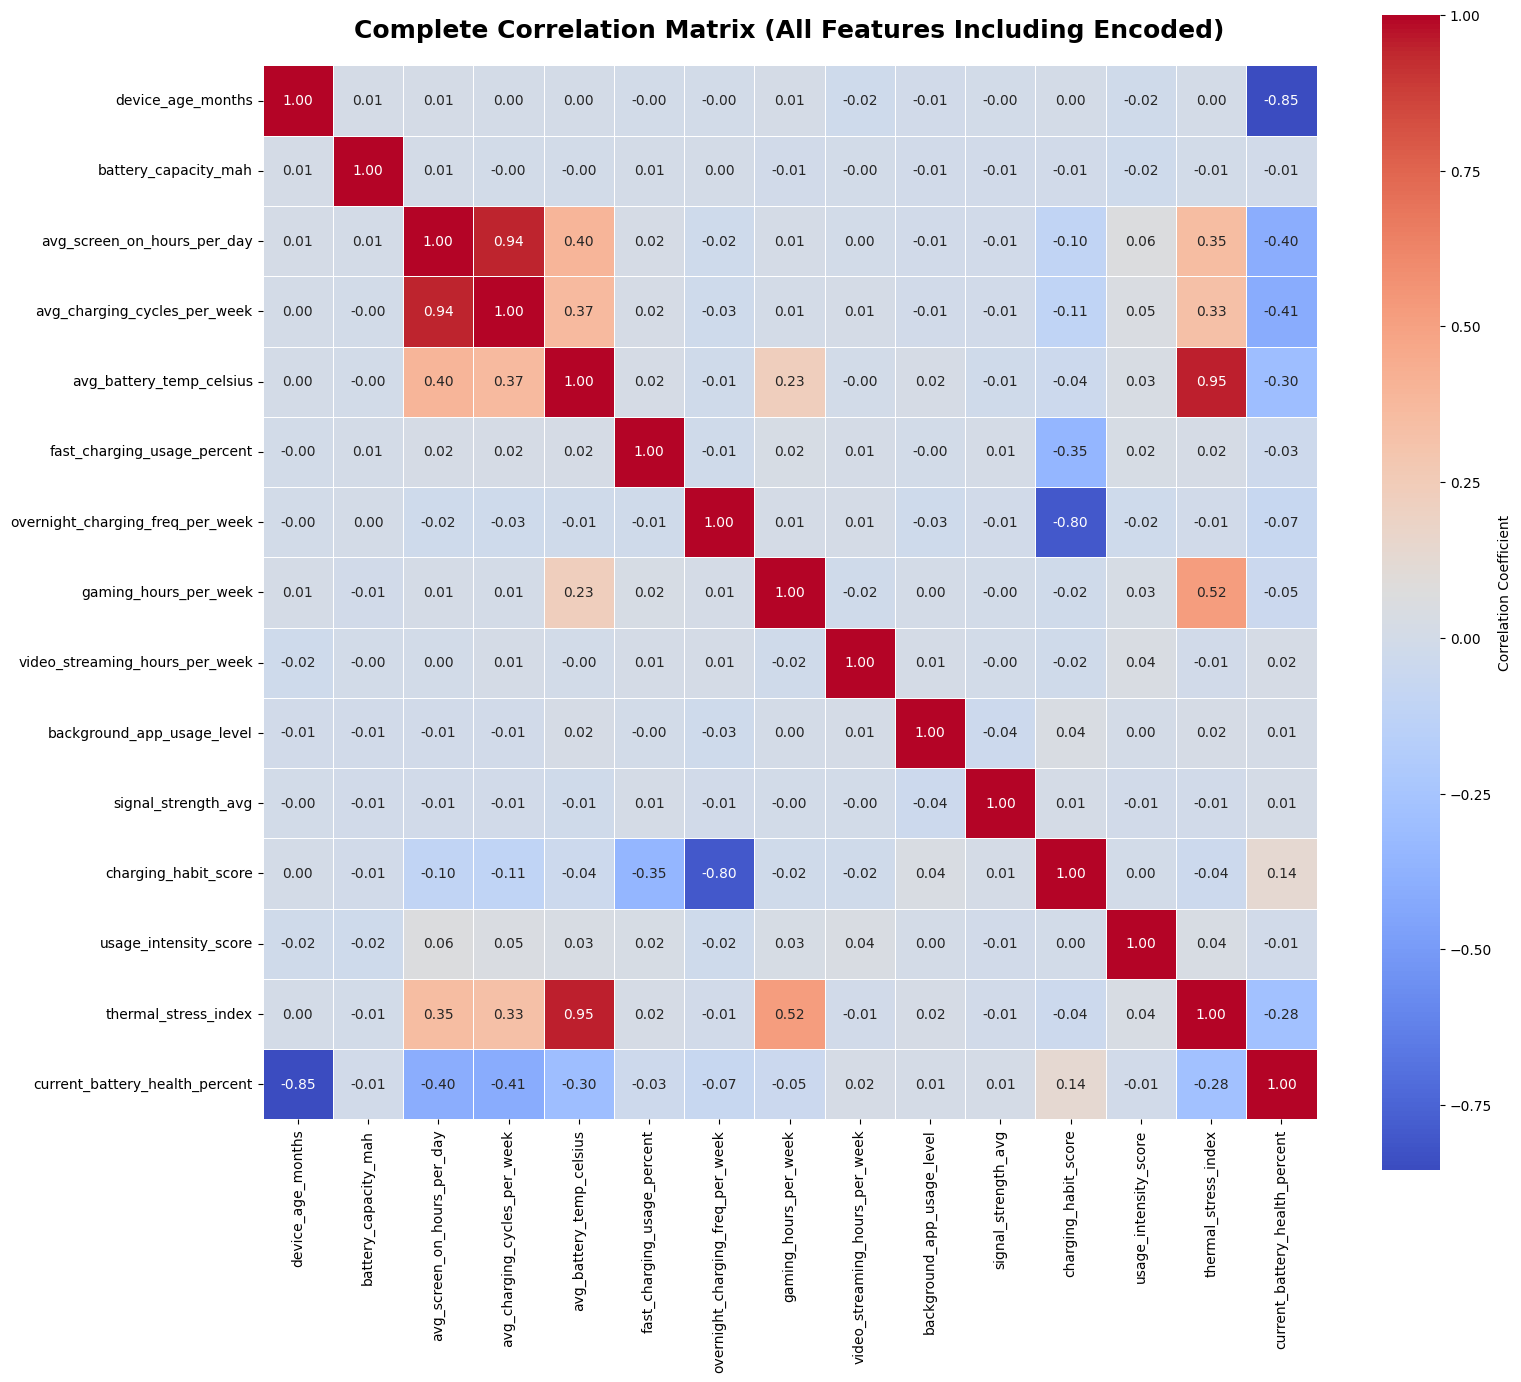

In [13]:
print("\n=== STEP 2: Creating Complete Correlation Matrix ===\n")

# Remove ONLY Device_ID (it's just an identifier)
X_for_analysis = X_df_encoded.drop(columns=['Device_ID'])

# Combine with target
df_complete = pd.concat([X_for_analysis, y], axis=1)

# Calculate correlation matrix
correlation_matrix = df_complete.corr()

# Visualize
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title("Complete Correlation Matrix (All Features Including Encoded)", 
          fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print("\n=== STEP 3: Analyzing Correlations ===\n")

# A) Correlation with Target (Battery Health)
print("📊 CORRELATION WITH TARGET (current_battery_health_percent):\n")
target_corr = correlation_matrix['current_battery_health_percent'].drop('current_battery_health_percent').sort_values(key=abs, ascending=False)
print(target_corr.to_string())

print("\n" + "="*60)

# B) High correlations BETWEEN features (multicollinearity check)
print("\n⚠️  MULTICOLLINEARITY CHECK (Correlations > 0.85 between features):\n")

high_corr_pairs = []
feature_columns = [col for col in correlation_matrix.columns if col != 'current_battery_health_percent']

for i in range(len(feature_columns)):
    for j in range(i+1, len(feature_columns)):
        corr_value = correlation_matrix.loc[feature_columns[i], feature_columns[j]]
        if abs(corr_value) > 0.85:
            high_corr_pairs.append({
                'Feature 1': feature_columns[i],
                'Feature 2': feature_columns[j],
                'Correlation': round(corr_value, 3)
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
    print(f"\n⚠️ Found {len(high_corr_pairs)} pairs with high correlation!")
else:
    print("✅ No problematic multicollinearity detected (all correlations < 0.85)")



=== STEP 3: Analyzing Correlations ===

📊 CORRELATION WITH TARGET (current_battery_health_percent):

device_age_months                  -0.854140
avg_charging_cycles_per_week       -0.409962
avg_screen_on_hours_per_day        -0.399347
avg_battery_temp_celsius           -0.300765
thermal_stress_index               -0.280187
charging_habit_score                0.137861
overnight_charging_freq_per_week   -0.067161
gaming_hours_per_week              -0.049027
fast_charging_usage_percent        -0.033425
video_streaming_hours_per_week      0.018082
background_app_usage_level          0.014968
usage_intensity_score              -0.013157
battery_capacity_mah               -0.011077
signal_strength_avg                 0.008209


⚠️  MULTICOLLINEARITY CHECK (Correlations > 0.85 between features):

                  Feature 1                    Feature 2  Correlation
   avg_battery_temp_celsius         thermal_stress_index        0.952
avg_screen_on_hours_per_day avg_charging_cycles_per_week 

In [15]:
# Drop highly correlated features
features_to_drop = [
    'thermal_stress_index',
    'avg_charging_cycles_per_week'
]

df = df.drop(columns=features_to_drop)


In [16]:
X = df.drop(columns=['current_battery_health_percent'])
y = df['current_battery_health_percent']



In [17]:
print(df.columns)


Index(['Device_ID', 'device_age_months', 'battery_capacity_mah',
       'avg_screen_on_hours_per_day', 'avg_battery_temp_celsius',
       'fast_charging_usage_percent', 'overnight_charging_freq_per_week',
       'gaming_hours_per_week', 'video_streaming_hours_per_week',
       'background_app_usage_level', 'signal_strength_avg',
       'charging_habit_score', 'usage_intensity_score',
       'current_battery_health_percent'],
      dtype='object')


In [18]:
X_df = X_df.select_dtypes(include=[np.number])


In [19]:
X = X_df.copy()


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
X_df.dtypes

device_age_months                     int64
battery_capacity_mah                  int64
avg_screen_on_hours_per_day         float64
avg_charging_cycles_per_week        float64
avg_battery_temp_celsius            float64
fast_charging_usage_percent         float64
overnight_charging_freq_per_week      int64
gaming_hours_per_week               float64
video_streaming_hours_per_week      float64
charging_habit_score                  int64
usage_intensity_score               float64
thermal_stress_index                float64
dtype: object

In [23]:
#base line linear regression model for comparison
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))


Linear Regression RMSE: 4.684694661840321
Linear Regression R2: 0.9299077439728853


In [24]:
# mlp = MLPRegressor(
#     hidden_layer_sizes=(32, 16),
#     activation='relu',
#     solver='adam',
#     alpha=0.001,
#     max_iter=500,
#     random_state=42
# )
mlp = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,        #early stopping
    validation_fraction=0.1,     #10% of training data for validation
    n_iter_no_change=20         #Stop if no improvement for 20 iterations
)

In [25]:
mlp.fit(X_train_scaled, y_train)


,loss,'squared_error'
,hidden_layer_sizes,"(32, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


In [26]:
y_pred_mlp = mlp.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mae = mean_absolute_error(y_test, y_pred_mlp)
r2 = r2_score(y_test, y_pred_mlp)

print("MLP RMSE:", rmse)
print("MLP MAE:", mae)
print("MLP R2:", r2)

MLP RMSE: 3.451356457135102
MLP MAE: 2.711677020718207
MLP R2: 0.9619559196338222


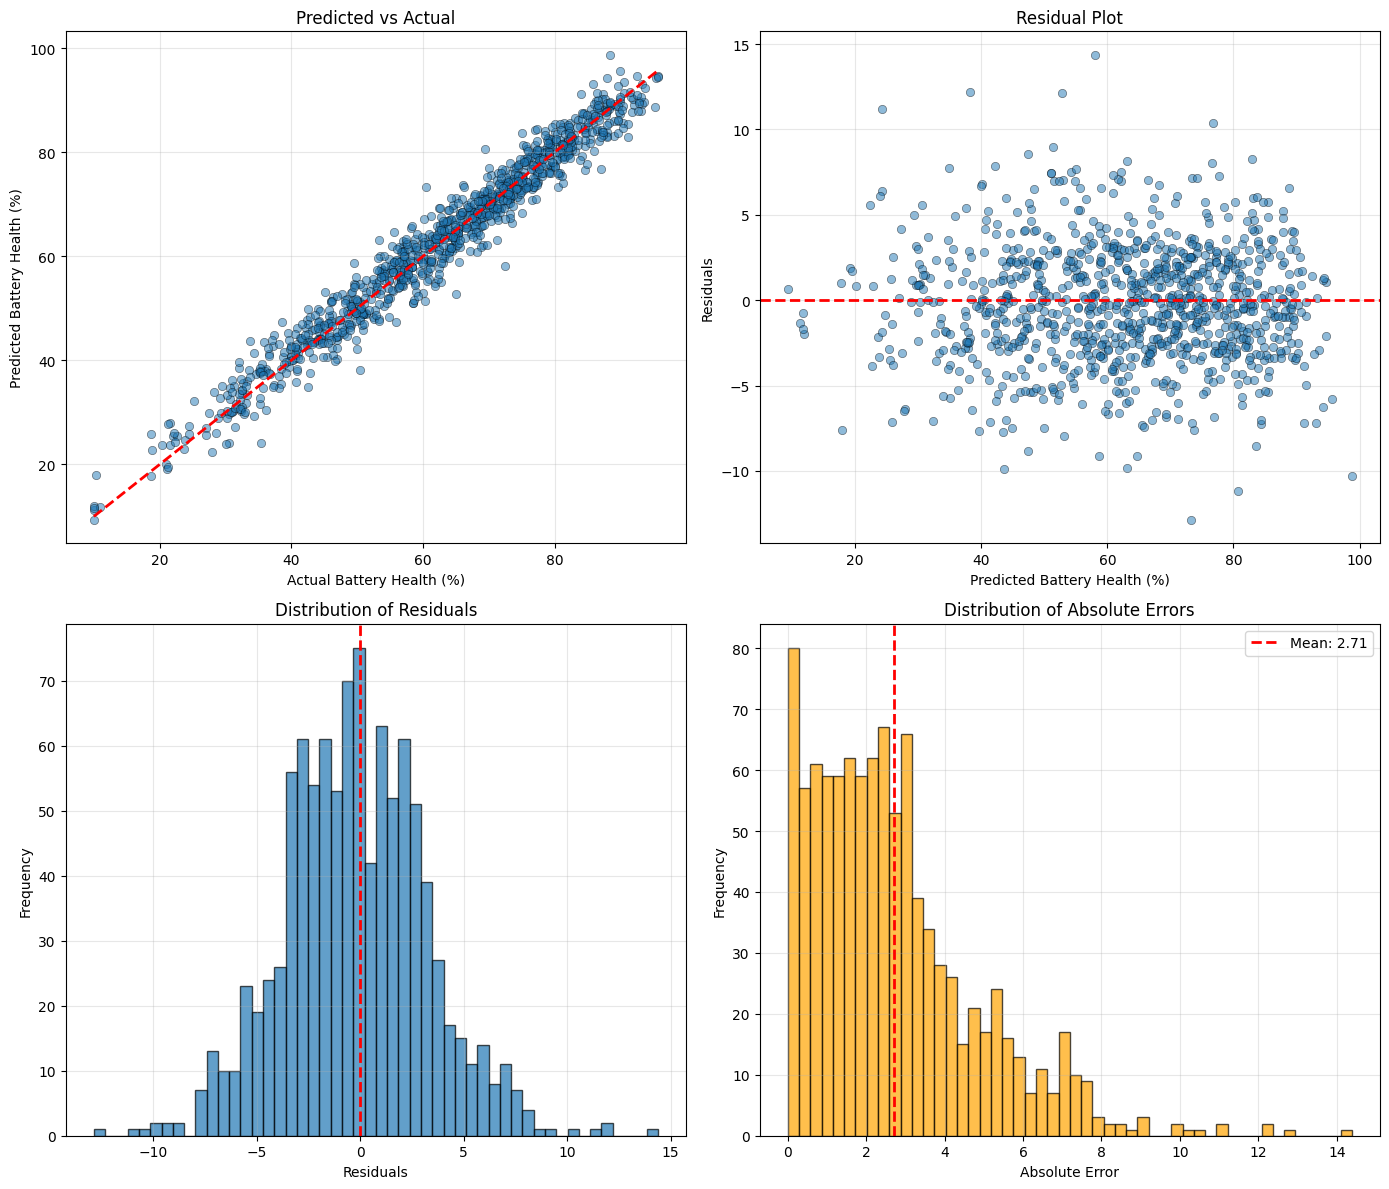


Residual Statistics:
Mean Residual: -0.2415
Std Residual: 3.4446
Min Error: 0.0025
Max Error: 14.3831
Mean Absolute Error: 2.7117


In [27]:
# Create a figure with multiple subplots for comprehensive evaluation
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Predicted vs Actual
axes[0, 0].scatter(y_test, y_pred_mlp, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Battery Health (%)')
axes[0, 0].set_ylabel('Predicted Battery Health (%)')
axes[0, 0].set_title('Predicted vs Actual')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals plot
residuals = y_test - y_pred_mlp
axes[0, 1].scatter(y_pred_mlp, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Battery Health (%)')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals distribution
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].grid(True, alpha=0.3)

# 4. Error distribution
errors = np.abs(residuals)
axes[1, 1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Absolute Error')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Absolute Errors')
axes[1, 1].axvline(x=errors.mean(), color='r', linestyle='--', lw=2, label=f'Mean: {errors.mean():.2f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print additional statistics
print(f"\nResidual Statistics:")
print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Residual: {residuals.std():.4f}")
print(f"Min Error: {errors.min():.4f}")
print(f"Max Error: {errors.max():.4f}")
print(f"Mean Absolute Error: {errors.mean():.4f}")

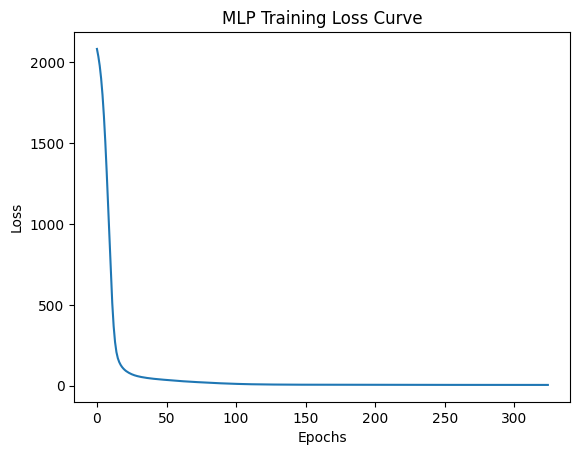

In [28]:
plt.plot(mlp.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.show()


In [29]:
mlp.n_iter_ # total number of epochs


325

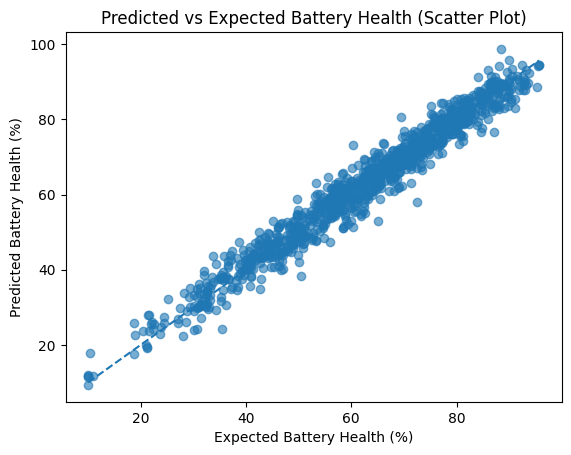

In [32]:
plt.figure()
plt.scatter(y_test, y_pred_mlp, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel("Expected Battery Health (%)")
plt.ylabel("Predicted Battery Health (%)")
plt.title("Predicted vs Expected Battery Health (Scatter Plot)")
plt.show()


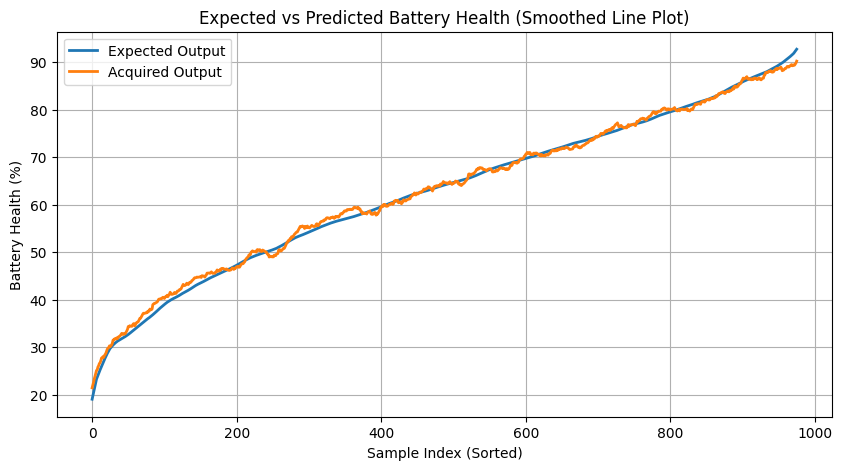

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Sort
sorted_idx = np.argsort(y_test.values)
y_true = y_test.values[sorted_idx]
y_pred = y_pred_mlp[sorted_idx]

# Moving average smoothing
window = 25
y_true_smooth = np.convolve(y_true, np.ones(window)/window, mode='valid')
y_pred_smooth = np.convolve(y_pred, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(y_true_smooth, label='Expected Output', linewidth=2)
plt.plot(y_pred_smooth, label='Acquired Output', linewidth=2)

plt.xlabel("Sample Index (Sorted)")
plt.ylabel("Battery Health (%)")
plt.title("Expected vs Predicted Battery Health (Smoothed Line Plot)")
plt.legend()
plt.grid(True)
plt.show()
